In [1]:
import numpy as np
import ot
import ot.plot
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances


from scipy.linalg import cholesky, inv, solve_triangular
from scipy.stats import multivariate_normal

`ot.low_rank._LR_Dysktra` implements the desired Dykstra's algorithm (warning: typo in the package). Using this, we write a command to solve the low-rank OT problem given a cost matrix $C$ and probability vectors $a, b$.

In [2]:
def lot(C, a, b, r, l, alpha, gamma, tol=1e-9, max_iter=1000, dykstra_iter=1000):
    # C = cost matrix
    # a, b = marginals
    # r = rank
    # l = regularization parameter
    # alpha = for stability
    # gamma = fixed step size

    n, m = C.shape

    # random initialization
    U = np.random.rand(n, r)
    V = np.random.rand(m, r)
    g = np.random.rand(r)

    for k in range(max_iter):
        xi1 = U * np.exp(-gamma*(C @ V @ np.diag(1/g) + l*np.log(U)))
        xi2 = V * np.exp(-gamma*(C.T @ U @ np.diag(1/g) + l*np.log(V)))
        xi3 = g * np.exp(-gamma*(-np.diag(U.T @ C @ V)/(g**2) + l*np.log(g)))
        U, V, g = ot.lowrank._LR_Dysktra(xi1, xi2, xi3, a, b, alpha, stopThr=tol, numItermax=dykstra_iter, warn=True)
        P = U @ np.diag(1 / g) @ V.T
        if k % 10 == 0:
            row_err = np.sum(np.abs(np.sum(P, axis=1) - a))
            col_err = np.sum(np.abs(np.sum(P, axis=0) - b))
            err = row_err + col_err
            print(f'Iteration {k}, error: {err}')
            print(f'Objective {np.sum(P * C) + l * np.sum(U * np.log(U)) + l * np.sum(V * np.log(V)) + l * np.sum(g * np.log(g))}')

    P = U @ np.diag(1 / g) @ V.T
    
    return P

### Example: 1D Gaussian Mixture

`ot.lowrank_sinkhorn` solve the low-rank OT problem based on samples.

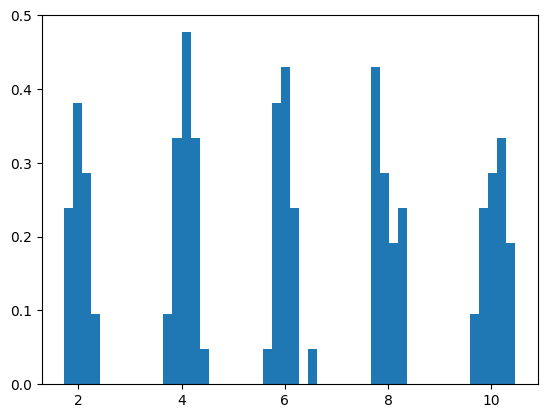

In [3]:
def sample_gmm(means, covariances, weights, n_samples, seed=None):
    """
    Efficiently samples from a Gaussian Mixture Model.

    Parameters:
    - means: (K, D) array of component means.
    - covariances: (K, D, D) array of component covariance matrices.
    - weights: (K,) array of component mixing portions (must sum to 1).
    - n_samples: int, number of samples to generate.
    - seed: int or None, random seed for reproducibility.

    Returns:
    - X: (n_samples, D) array of generated samples.
    - y: (n_samples,) array of component labels (0 to K-1) corresponding to X.
    """
    rng = np.random.default_rng(seed)
    
    # Ensure inputs are numpy arrays
    means = np.asarray(means)
    covariances = np.asarray(covariances)
    weights = np.asarray(weights)
    
    # Validate shapes
    K, D = means.shape
    
    # 1. Determine how many samples to draw from each component
    # This vectorizes the component selection process
    n_samples_per_component = rng.multinomial(n_samples, weights)
    
    # Pre-allocate memory for speed
    X = np.empty((n_samples, D))
    y = np.empty(n_samples, dtype=int)
    
    # 2. Generate samples for each component in batches
    current_idx = 0
    for k, count in enumerate(n_samples_per_component):
        if count > 0:
            # Generate 'count' samples efficiently using optimized C-backend
            samples = rng.multivariate_normal(means[k], covariances[k], size=count)
            
            # Fill the pre-allocated arrays
            X[current_idx : current_idx + count] = samples
            y[current_idx : current_idx + count] = k
            
            current_idx += count
            
    # 3. Shuffle the result to mix components randomly
    # (Otherwise, output is sorted by component 0, then 1, etc.)
    perm = rng.permutation(n_samples)
    
    return X[perm], y[perm]

def gmm_log_density(X, weights, means, covariances):
    n_samples, n_features = X.shape
    K = len(weights)
    prob = np.zeros((n_samples, K))

    for k in range(K):
        mean = means[k]
        cov = covariances[k]
        prob[:, k] = multivariate_normal.pdf(X, mean=mean, cov=cov) * weights[k]
    
    density = np.sum(prob, axis=1)
    log_density = np.log(density)
    cond_densities = prob / density[:, np.newaxis]

    return log_density, cond_densities


# 1d Gaussian mixture
means = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
K = len(means)
s = 0.2
covariances = np.ones(K).reshape(-1, 1, 1) * (s**2)
weights = np.ones(K) / K

n = 120
m = 100

# sample from the mixture
np.random.seed(0)
X, c_X = sample_gmm(means, covariances, weights, n)
idx = np.argsort(X[:, 0]) # sort for better visualization
X = X[idx]
c_X = c_X[idx]

# plot the histogram
plt.hist(X.flatten(), bins=50, density=True)
plt.show()


Y, c_Y = sample_gmm(means, covariances, weights, m)
idy = np.argsort(Y[:, 0]) # sort for better visualization
Y = Y[idy]
c_Y = c_Y[idy]


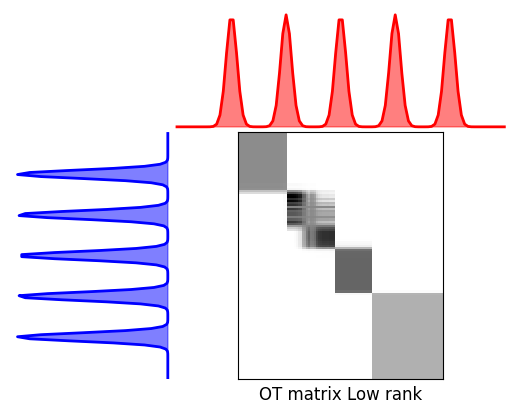

In [4]:
a = np.ones(n) / n
b = np.ones(m) / m



Q, R, g, log = ot.lowrank_sinkhorn(
    X,
    Y,
    a,
    b,
    rank=K,
    init="random",
    gamma_init="rescale",
    rescale_cost=True,
    warn=False,
    log=True,
)
P = log["lazy_plan"][:]

# data to pdf
x_pdf = np.exp(gmm_log_density(np.linspace(0, 12, n).reshape(-1, 1), weights, means, covariances)[0])
y_pdf = np.exp(gmm_log_density(np.linspace(0, 12, m).reshape(-1, 1), weights, means, covariances)[0])

ot.plot.plot1D_mat(x_pdf.flatten(), y_pdf.flatten(), P, "OT matrix Low rank")
plt.show()

Let us compute the cost matrix $C$ (squared Euclidean distances) and test the code we wrote above.

Iteration 0, error: 9.752981651456327e-10
Objective 16.259323685029656
Iteration 10, error: 6.771826415591375e-10
Objective 16.256920210456947
Iteration 20, error: 7.385793122927087e-10
Objective 16.253880635232235
Iteration 30, error: 7.840326530367259e-10
Objective 16.249832648144874
Iteration 40, error: 7.547667092017152e-10
Objective 16.244429759214405
Iteration 50, error: 7.544482902993588e-10
Objective 16.23743993856529
Iteration 60, error: 7.540523899729479e-10
Objective 16.228831185462717
Iteration 70, error: 7.535876870440328e-10
Objective 16.218770974206468
Iteration 80, error: 7.530626695145815e-10
Objective 16.207510678285406
Iteration 90, error: 7.524892341181921e-10
Objective 16.195236871819535
Iteration 100, error: 7.518706126447006e-10
Objective 16.181991706686247
Iteration 110, error: 7.512027718620251e-10
Objective 16.167683550776236
Iteration 120, error: 7.504785369538691e-10
Objective 16.1521471422821
Iteration 130, error: 7.496894632863516e-10
Objective 16.13520858

/opt/miniconda3/envs/test/lib/python3.11/site-packages/ot/lowrank.py:310: UserWarning: Dykstra did not converge. You might want to increase the number of iterations `numItermax` 
  warnings.warn(


Iteration 5970, error: 1.034295028096155e-09
Objective 2.0708911236387624
Iteration 5980, error: 1.0684614807493498e-09
Objective 2.0645902636646074
Iteration 5990, error: 1.1043467407906293e-09
Objective 2.058342871510191
Iteration 6000, error: 1.1420459647415449e-09
Objective 2.052151743812323
Iteration 6010, error: 1.181656475793269e-09
Objective 2.046019645366701
Iteration 6020, error: 1.223278926071325e-09
Objective 2.0399493009342087
Iteration 6030, error: 1.26701693407838e-09
Objective 2.033943386412364
Iteration 6040, error: 1.3129760317170946e-09
Objective 2.0280045194246648
Iteration 6050, error: 1.361263430102455e-09
Objective 2.02213524937971
Iteration 6060, error: 1.4119881288493508e-09
Objective 2.0163380470462835
Iteration 6070, error: 1.4652587389946126e-09
Objective 2.010615293680658
Iteration 6080, error: 1.5211841369877632e-09
Objective 2.004969269728985
Iteration 6090, error: 1.579871244244968e-09
Objective 1.9994021431122333
Iteration 6100, error: 1.641424485915310

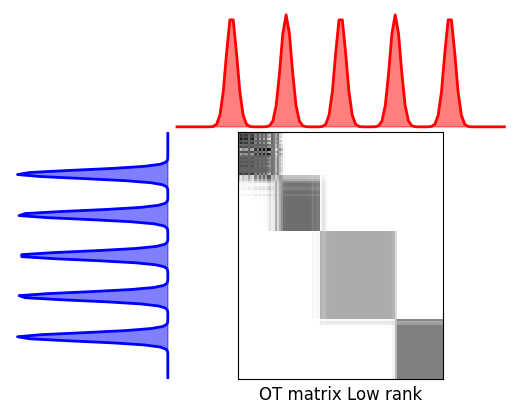

In [5]:
C = pairwise_distances(X, Y, metric='sqeuclidean')
np.random.seed(0) # set seed for initialization
P = lot(C, a, b, r=K, l=0.00001, alpha=1e-3, gamma=1e-3, tol=1e-9, max_iter=10000, dykstra_iter=500)
ot.plot.plot1D_mat(x_pdf.flatten(), y_pdf.flatten(), P, "OT matrix Low rank")
plt.show()

### Quadratic

In [ ]:
def lot_quad(C, K, L, a, b, r, l, alpha, gamma, tol=1e-9, max_iter=1000, dykstra_iter=1000):
    # C = cost matrix
    # K = row quadratic term
    # L = column quadratic term
    # a, b = marginals
    # r = rank
    # l = regularization parameter
    # alpha = for stability
    # gamma = fixed step size

    n, m = C.shape

    # random initialization
    U = np.random.rand(n, r)
    V = np.random.rand(m, r)
    g = np.random.rand(r)

    for k in range(max_iter):
        P = U @ np.diag(1/g) @ V.T
        M = C + (K + K.T) @ P + P @ (L + L.T)
        xi1 = U * np.exp(-gamma*(M @ V @ np.diag(1/g) + l*np.log(U)))
        xi2 = V * np.exp(-gamma*(M.T @ U @ np.diag(1/g) + l*np.log(V)))
        xi3 = g * np.exp(-gamma*(-np.diag(U.T @ M @ V)/(g**2) + l*np.log(g)))
        U, V, g = ot.lowrank._LR_Dysktra(xi1, xi2, xi3, a, b, alpha, stopThr=tol, numItermax=dykstra_iter, warn=True)
        P = U @ np.diag(1 / g) @ V.T
        if k % 10 == 0:
            row_err = np.sum(np.abs(np.sum(P, axis=1) - a))
            col_err = np.sum(np.abs(np.sum(P, axis=0) - b))
            err = row_err + col_err
            print(f'Iteration {k}, error: {err}')
            print(f'Objective {np.sum(P * C) + l * np.sum(U * np.log(U)) + l * np.sum(V * np.log(V)) + l * np.sum(g * np.log(g))}')

    P = U @ np.diag(1 / g) @ V.T
    
    return P